In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# -----------------
# data
# -----------------
x = np.random.normal(50, 10, 1000)
x = (x - x.min()) / (x.max() - x.min())
x = x.reshape(-1, 1).astype("float32")

# -----------------
# encoder
# -----------------
inputs = layers.Input(shape=(1,))

h = layers.Dense(8, activation="relu")(inputs)

z_mean = layers.Dense(1)(h)
z_log_var = layers.Dense(1)(h)

def sample(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], 1))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sample)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

# -----------------
# decoder
# -----------------
latent_inputs = layers.Input(shape=(1,))

x_dec = layers.Dense(8, activation="relu")(latent_inputs)

outputs = layers.Dense(1, activation="sigmoid")(x_dec)

decoder = Model(latent_inputs, outputs)

# -----------------
# VAE model
# -----------------
class VAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.square(data - reconstruction)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

vae.fit(x, epochs=50, batch_size=32)

# -----------------
# test
# -----------------
mean, log_var, latent = encoder.predict(x[:5])

print("Mean:")
print(mean)

print("\nLog Var:")
print(log_var)

print("\nLatent z:")
print(latent)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 0.0310 - loss: 0.0436 - reconstruction_loss: 0.0125
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 0.0126 - loss: 0.0385 - reconstruction_loss: 0.0259
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 0.0030 - loss: 0.0256 - reconstruction_loss: 0.0226
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 0.0030 - loss: 0.0239 - reconstruction_loss: 0.0208
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0035 - loss: 0.0398 - reconstruction_loss: 0.0363
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0010 - loss: 0.0122 - reconstruction_loss: 0.0111
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 6.6981e-04 - loss: 0.0119 - reconstruction_loss: 0.0113
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0014 - loss: 0.0161 - reconstruction_loss: 0.0148
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 8.6525e-04 - loss: 0.0114 - re

In [17]:
x[:5]

array([[0.5811533 ],
       [0.42769936],
       [0.4807844 ],
       [0.55054927],
       [0.40167558]], dtype=float32)

In [20]:
vae.fit(x, epochs=50, batch_size=32)

Epoch 1/50


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 2.4587e-07 - loss: 0.0108 - reconstruction_loss: 0.0108
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 1.6764e-07 - loss: 0.0250 - reconstruction_loss: 0.0250
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 3.2037e-07 - loss: 0.0162 - reconstruction_loss: 0.0162
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 1.4529e-07 - loss: 0.0216 - reconstruction_loss: 0.0216
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 5.5879e-08 - loss: 0.0141 - reconstruction_loss: 0.0141
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 1.4156e-06 - loss: 0.0163 - reconstruction_loss: 0.0163
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 2.9802e-08 - loss: 0.0092 - reconstruction_loss: 0.0092
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 1.7136e-07 - loss: 0.0095 - reconstruction_loss: 0.0095
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 2.5332e-07 - 

In [21]:
sample = x[:5]

reconstructed = vae.decoder(
    vae.encoder(sample)[2]
)

print("Original:")
print(sample)

print("\nReconstructed:")
print(reconstructed.numpy())

Original:
[[0.5811533 ]
 [0.42769936]
 [0.4807844 ]
 [0.55054927]
 [0.40167558]]

Reconstructed:
[[0.46060932]
 [0.4632416 ]
 [0.4628041 ]
 [0.45760766]
 [0.4671481 ]]


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# -----------------------
# LOAD MNIST
# -----------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)

# -----------------------
# ENCODER
# -----------------------
latent_dim = 2

inputs = layers.Input(shape=(784,))

h = layers.Dense(256, activation="relu")(inputs)

z_mean = layers.Dense(latent_dim)(h)

z_log_var = layers.Dense(latent_dim)(h)

def sample(args):
    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=(tf.shape(z_mean)[0], latent_dim)
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sample)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

# -----------------------
# DECODER
# -----------------------
latent_inputs = layers.Input(shape=(latent_dim,))

h_dec = layers.Dense(256, activation="relu")(latent_inputs)

outputs = layers.Dense(784, activation="sigmoid")(h_dec)

decoder = Model(latent_inputs, outputs)

# -----------------------
# VAE
# -----------------------
class VAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction),
                    axis=1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

vae.fit(x_train, epochs=10, batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - kl_loss: 2.6662 - loss: 49.1958 - reconstruction_loss: 46.5296
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - kl_loss: 2.9156 - loss: 43.7272 - reconstruction_loss: 40.8116
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.1153 - loss: 42.6565 - reconstruction_loss: 39.5412
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 3.3790 - loss: 44.2796 - reconstruction_loss: 40.9006
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.4223 - loss: 41.8038 - reconstruction_loss: 38.3816
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 3.5928 - loss: 40.3578 - reconstruction_loss: 36.7650
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 3.6469 - loss: 40.9593 - reconstruction_loss: 37.3124
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 3.8028 - loss: 41.8056 - reconstruction_loss: 38.0028
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step 

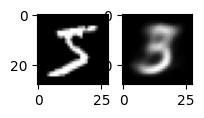

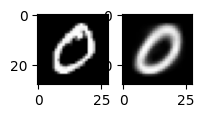

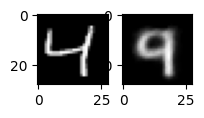

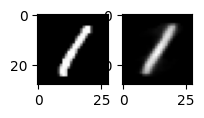

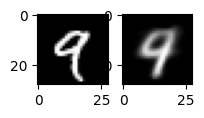

In [27]:
import matplotlib.pyplot as plt

sample = x_train[:5]

reconstructed = vae.decoder(
    vae.encoder(sample)[2]
).numpy()

for i in range(5):

    plt.figure(figsize=(2,1))

    # original
    plt.subplot(1,2,1)
    plt.imshow(sample[i].reshape(28,28), cmap="gray")

    # reconstructed
    plt.subplot(1,2,2)
    plt.imshow(reconstructed[i].reshape(28,28), cmap="gray")

    plt.show()

In [26]:
vae.fit(
    x_train,
    epochs=40,
    batch_size=128
)

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 4.4647 - loss: 40.0009 - reconstruction_loss: 35.5361
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.2699 - loss: 38.4145 - reconstruction_loss: 34.1446
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.4990 - loss: 38.0271 - reconstruction_loss: 33.5280
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 4.4609 - loss: 38.6823 - reconstruction_loss: 34.2213
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.5799 - loss: 37.9272 - reconstruction_loss: 33.3474
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.6086 - loss: 36.7304 - reconstruction_loss: 32.1219
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.4533 - loss: 36.3882 - reconstruction_loss: 31.9349
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.5506 - loss: 38.5351 - reconstruction_loss: 33.9845
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - k

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


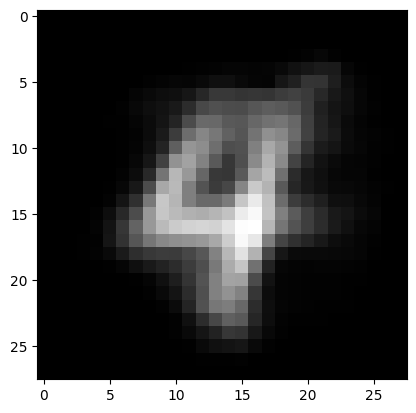

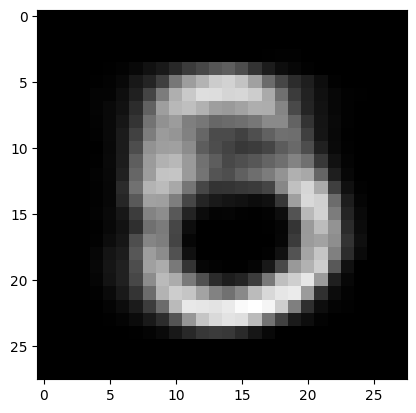

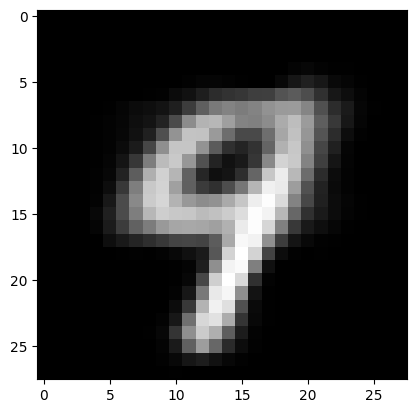

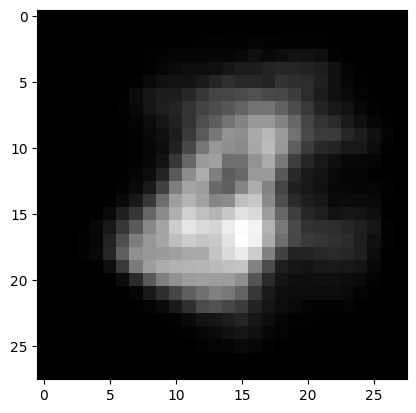

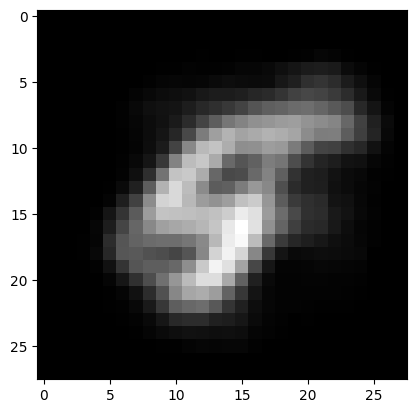

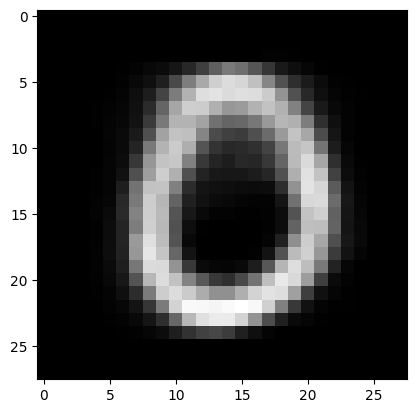

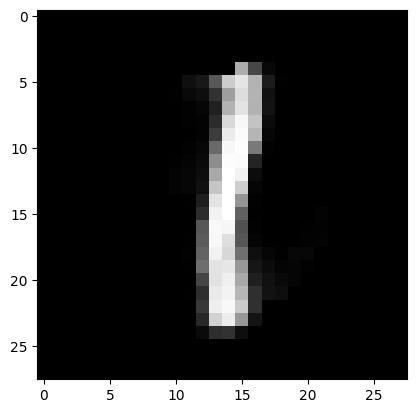

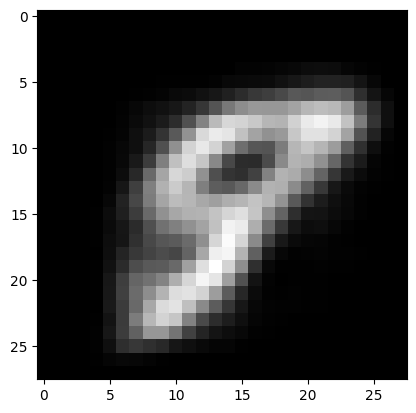

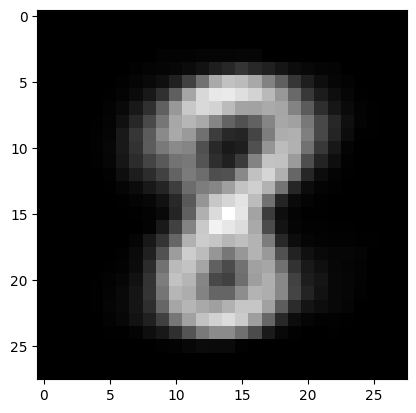

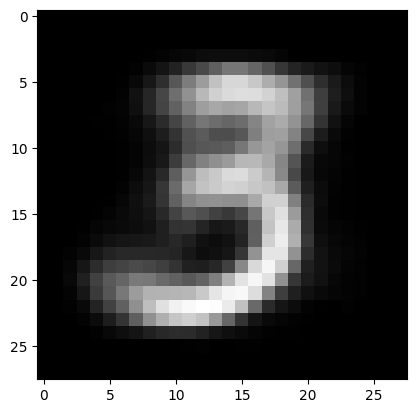

In [28]:
random_z = np.random.normal(size=(10, 2))

generated = vae.decoder.predict(random_z)

for i in range(10):

    plt.imshow(generated[i].reshape(28,28), cmap="gray")
    plt.show()